In [71]:
import pygyre as pg
import numpy as np
import scipy as cp
from scipy import integrate
import matplotlib.pyplot as plt
from TDECalculator import TDECalculator

In [72]:
Masses, Gammas = np.loadtxt('M-gamma.txt', unpack=True)

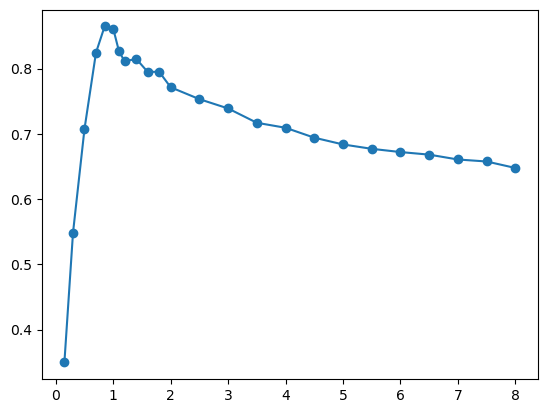

In [73]:
plt.plot(Masses, Gammas, '-o')

In [74]:
import os

def get_folder_names(directory_path):
    """
    Returns a list of folder names within the specified directory.
    """
    folder_names = []
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)
        if os.path.isdir(item_path):
            folder_names.append(item)
    return folder_names

masses = np.sort(get_folder_names('star-files')).tolist()

import re

def parse_numbers(strings):
    numbers = []
    pattern = re.compile(r'-?\d+(?:p\d+|\.\d+)?')

    for s in strings:
        matches = pattern.findall(s)
        for match in matches:
            # Replace 'p' with '.' to convert formats like 0p15 to 0.15
            number_str = match.replace('p', '.')
            try:
                numbers.append(float(number_str))
            except ValueError:
                pass  # Skip malformed numbers

    return np.array(numbers)

mass_vals = parse_numbers(masses)

In [75]:
Mbh = 1e6
a = 0.5
n = 1000
beta_f = 12.0

In [93]:
def rps_equal_beta(masses, Mbh):
    Rps = []
        
    for star_name in masses:
        summary = pg.read_output(f"star-files/{star_name}/summary.h5")
        detail0 = pg.read_output(f"star-files/{star_name}/detail.l2.n+0.h5")
        r = detail0['x'] # radial vector, in units of R_star
        rho = detail0['rho'] # density of the star, in g/cm^3
        rho_average = summary['M_star'][0] / ((4/3) * np.pi * (summary['R_star'][0])**3) # average density of the star, in g/cm^3
        rho_center = detail0['rho'][0] # central density of the star, in g/cm^3
        
        Mstar      = summary['M_star'][0] / 1.9884e33  # solar masses
        mass_ratio = Mstar / Mbh
        Rstar      = (summary['R_star'][0]/100) / (Mbh*1476.55)
        Rtidal     = Rstar / mass_ratio**(1/3)

        if (rho_center/rho_average < 500): # set the beta parameter according to the fitting formula found in ref [???], treated as a UV theory
            beta_crit = 0.5 * (rho_center/rho_average)**(1/3)
        else:
            beta_crit = 0.39 * (rho_center/rho_average)**(1/2.3)
        Rp = Rtidal / beta_crit # pericenter distance

        Rps.append(Rp)
    
    return Rps

In [94]:
Rps = rps_equal_beta(masses, Mbh)

In [96]:
def gammas(masses, label, Mbh, Rps, a, n):
    gammas = []

    for i in range(len(masses)):
        calc = TDECalculator(masses[i], label, Mbh, Rps[i], a, n)

        gamma = np.max((calc.TidalEnergy) / np.abs(calc.U))
        gammas.append(gamma)

    return gammas
    

In [106]:
g = gammas(masses, 'rel', Mbh, Rps, a, n)

In [107]:
g2 = gammas(masses, 'rel', Mbh, Rps, 0.0, n)

In [109]:
g3 = gammas(masses, 'rel', Mbh, Rps, -a, n)

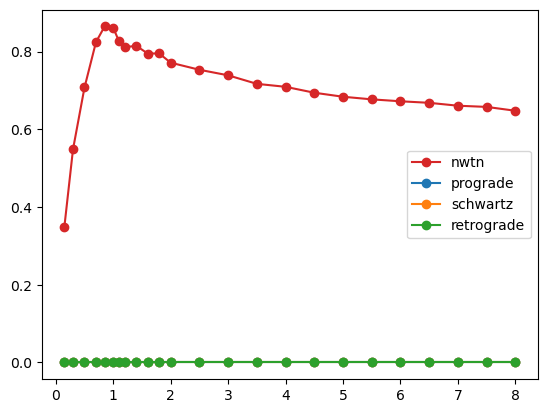

In [113]:
plt.plot(Masses, Gammas, '-o', color='C3', label='nwtn')
plt.plot(mass_vals, g, '-o', label='prograde')
plt.plot(mass_vals, g2, '-o', label='schwartz')
plt.plot(mass_vals, g3, '-o', label='retrograde')
plt.legend()